In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import seaborn as sns 
from statsmodels.tsa.holtwinters import (ExponentialSmoothing, 
                                         SimpleExpSmoothing, 
                                         Holt)

In [9]:
#plot 한글 적용
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [20]:
plt.set_cmap('cubehelix')
sns.set_palette('cubehelix')

COLORS = [plt.cm.cubehelix(x) for x in [0.1, 0.3, 0.5, 0.7]]

<Figure size 640x480 with 0 Axes>

### 데이터 불러오기(구글 2011~2018년도)

In [5]:
# Yahoo Finance에서 수집한 CSV
file_path = "../Data-collection/dailyStock"
target = "GOOG"
file_path = f"{file_path}/{target}.csv"
df = pd.read_csv(file_path, encoding="utf-8")

df['Date'] = pd.to_datetime(df['Date']) # 날짜로 변환
df = df.set_index('Date')               # Date를 인덱스로 설정
df = df.loc['2011-01-01':'2018-12-31']  # 분석 기간

### 훈련데이터와 검증데이터로 분리

In [15]:
train_indices = goog.index.year < 2018
goog_train = goog[train_indices]
goog_test = goog[~train_indices]
test_length = len(goog_test)

### 주가 도식화

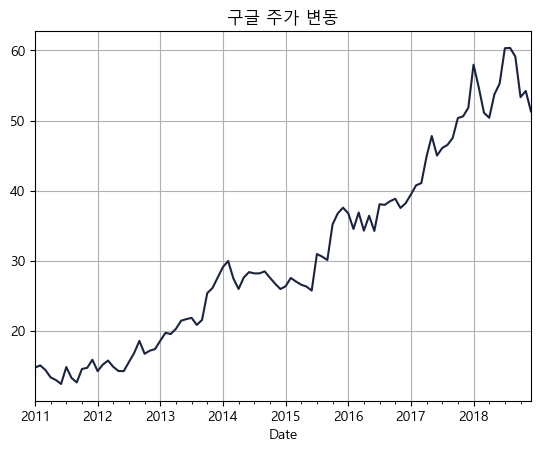

In [30]:
goog.plot(title= "구글 주가 변동").grid(True)
plt.show()

### 단순 지수 평활화 도식화

In [28]:
# α값 0.2 SES모델 생성
ses_1 = SimpleExpSmoothing(goog_train).fit(smoothing_level=0.2)
ses_forecast_1 = ses_1.forecast(test_length) #예측 범위를 설정

# α값 0.5 SES모델 생성
ses_2 = SimpleExpSmoothing(goog_train).fit(smoothing_level=0.5)
ses_forecast_2 = ses_2.forecast(test_length) #예측 범위를 설정

# SES모델 추정 적합 α값으로 생성
ses_3 = SimpleExpSmoothing(goog_train).fit()
alpha = ses_3.model.params['smoothing_level']
ses_forecast_3 = ses_3.forecast(test_length) #예측 범위를 설정

C:\Users\ckddn\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\ckddn\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


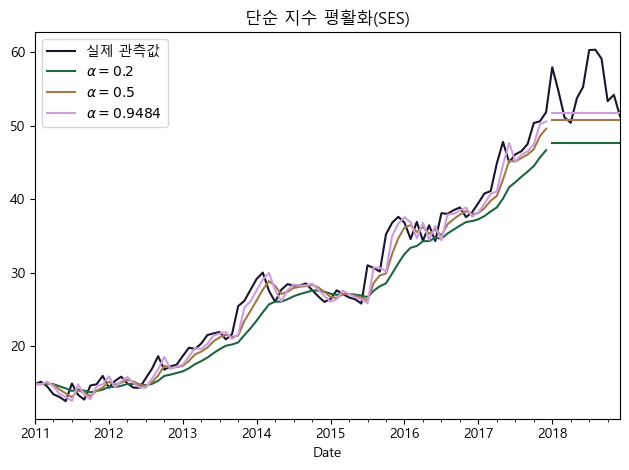

In [38]:
goog.plot(color=COLORS[0], 
          title='단순 지수 평활화(SES)',
          label='실제 관측값',
          legend=True)

ses_forecast_1.plot(color=COLORS[1], legend=True, label=r'$\alpha=0.2$')
ses_1.fittedvalues.plot(color=COLORS[1])

ses_forecast_2.plot(color=COLORS[2], legend=True, label=r'$\alpha=0.5$')
ses_2.fittedvalues.plot(color=COLORS[2])

ses_forecast_3.plot(color=COLORS[3], legend=True, label=r'$\alpha={0:.4f}$'.format(alpha))
ses_3.fittedvalues.plot(color=COLORS[3])

plt.tight_layout()
plt.show()

### 홀트 평활화 도식화

In [36]:
#선형 추세 모델
hs_1 = Holt(goog_train).fit()
hs_forecast_1 = hs_1.forecast(test_length)

#지수형 추세 모델
hs_2 = Holt(goog_train, exponential=True).fit()
hs_forecast_2 = hs_2.forecast(test_length)

#감쇠(damped) 추세 모델 
hs_3 = Holt(goog_train, exponential=False, damped=True).fit(damping_slope=0.99)
hs_forecast_3 = hs_3.forecast(test_length)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23248\1482775509.py:10: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  hs_3 = Holt(goog_train, exponential=False, damped=True).fit(damping_slope=0.99)
C:\Users\ckddn\anaconda3\Lib\site-packages\pandas\util\_decorators.py:213: FutureWarning: the 'damping_slope' keyword is deprecated, use 'damping_trend' instead.
  return func(*args, **kwargs)


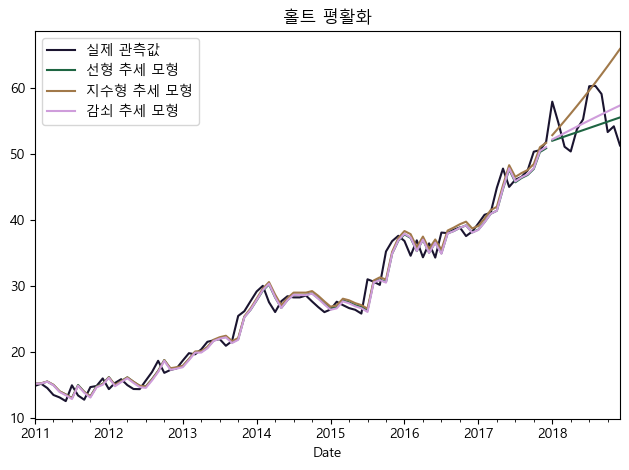

In [46]:
goog.plot(color=COLORS[0],
          title="홀트 평활화",
          label='실제 관측값',
          legend=True)

hs_forecast_1.plot(color=COLORS[1], legend=True, label='선형 추세 모형')
hs_1.fittedvalues.plot(color=COLORS[1])

hs_forecast_2.plot(color=COLORS[2], legend=True, label='지수형 추세 모형')
hs_2.fittedvalues.plot(color=COLORS[2])

hs_forecast_3.plot(color=COLORS[3], legend=True, label='감쇠 추세 모형')
hs_3.fittedvalues.plot(color=COLORS[3])

plt.tight_layout()
plt.show()

### 홀트 윈터스 계절 평활화

In [40]:
SEASONAL_PERIODS = 12

hw_1 = ExponentialSmoothing(goog_train, 
                            trend='mul', 
                            seasonal='add', 
                            seasonal_periods=SEASONAL_PERIODS).fit()
hw_forecast_1 = hw_1.forecast(test_length)

hw_2 = ExponentialSmoothing(goog_train, 
                            trend='mul', 
                            seasonal='add', 
                            seasonal_periods=SEASONAL_PERIODS, 
                            damped=True).fit()
hw_forecast_2 = hw_2.forecast(test_length)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23248\552213631.py:9: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  hw_2 = ExponentialSmoothing(goog_train,


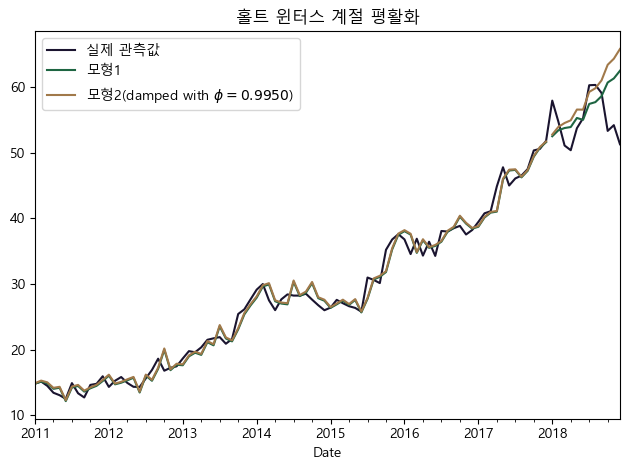

In [45]:
goog.plot(color=COLORS[0],
          title="홀트 윈터스 계절 평활화",
          label='실제 관측값',
          legend=True)

hw_1.fittedvalues.plot(color=COLORS[1])
hw_forecast_1.plot(color=COLORS[1], legend=True, label='모형1')

phi = hw_2.model.params['damping_trend']
plot_label = f'모형2(damped with $\phi={phi:.4f}$)'

hw_2.fittedvalues.plot(color=COLORS[2])
hw_forecast_2.plot(color=COLORS[2], legend=True, 
                   label=plot_label)

plt.tight_layout()
plt.show()